# Análise Exploratória de Dados — NPS Preditivo

Este notebook tem como objetivo investigar quais fatores estão impactando mais o NPS (Net Promoter Score) de um e-commerce.

Nesta análise, exploraremos uma base de dados relacionados a pedidos, logística, atendimento e perfil dos clientes para identificar padrões que expliquem a variação do NPS e buscar pontos de melhoria.

O foco não será no código ou apenas descrever os dados, mas **entender** as causas por trás da insatisfação ou satisfação dos clientes.

Iremos passar explicando cada etapa da análise, buscando deixar claro o motivo ou entendimento do que acontece a cada passo.

Antes de iniciarmos a análise, é importante termos o seguinte conhecimento sobre NPS:

- Detratores - 0 a 6
- Neutros 7 e 8
- Promotores - 9 e 10

Detratores são clientes insatisfeitos que prejudicam a empresa.<br>
Neutros são clientes passivos.<br>
Promotores são clientes fiéis e recomendam a empresa.

# Bibliotecas

Iniciamos importando as bibliotecas que serão necessárias à análise exploratória, manipulação de dados e visualização gráfica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importação dos Dados

Os dados são carregados a partir de um arquivo CSV para um DataFrame.

In [2]:
df = pd.read_csv("../data/desafio_nps_fase_1.csv")

# Análise Inicial e Estatística Básica

Antes de qualquer investigação, é fundamental entender a estrutura da base de dados.

Utilizamos funções como `head()`, `info()`, `describe()` e verificação de valores nulos para responder perguntas essenciais:

- Como os dados estão organizados
- Quais variáveis estão disponíveis
- Quantidade de registros
- Tipos de dados
- Estatísticas descritivas iniciais
- Presença de valores ausentes

Essa etapa fornece a visão geral necessária para conduzir a análise com segurança.

In [3]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [4]:
df['customer_id'].value_counts().head(10)

customer_id
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [6]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [7]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

# Entendendo a Distribuição do NPS

Como a base possui cerca de 2.500 registros, é possível trabalhar com a população completa sem necessidade de amostragem.

O primeiro passo é entender como o NPS se distribui. Antes de investigar causas, precisamos compreender o comportamento geral das notas atribuídas pelos clientes.

A análise começa observando métricas estatísticas básicas e visualizações que nos permitam enxergar padrões na distribuição.

Para isso vamos utilizar o `describe()` e plotar um Histograma para visualizar a distribuição do NPS.

---

### Amostra (Extra)

_Esta parte de **Amostra** não faz parte da análise, somente uma informação extra referente a matéria relacionada ao estudo do período em que esse projeto foi desenvolvido_

Como parte do conteúdo visto no curso, ao analisar amostras temos outros pontos importantes a serem considerados.<br>
Em um cenário onde houvesse uma enorme quantidade de dados, analisar a população poderia ser inviável por diversos fatores, como tempo de processamento, acesso a todos os dados e até custos. Dessa maneira seria necessário uma amostragem.<br>
Com uma amostragem, devemos antes de tudo analisar como essa amostra foi selecionada, evitando vies de pesquisa e aplicar um intervalo de confiança.<br>
Analisamos nossa amostra para entender se nossos dados seguem uma normalidade ou não. Em muitos cenários, apenas vendo o gráfico já conseguimos deduzir, mas o ideal é sempre realizar um Teste de Hipotese com _Shapiro Wilk_. Esse teste nos dará um resultado em _p-value_, onde dependendo do resultado aplicamos soluções como _z-score_ ou _bootstrap_.

In [8]:
df["nps_score"].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64

Com o `describe()` observamos que:

- A média do NPS é baixa: 4.37
- Metade dos clientes avaliou abaixo de 4.4
- 75% deram notas abaixo de 6.1

Esses números já indicam um cenário de atenção. Para visualizar melhor, utilizamos um histograma.

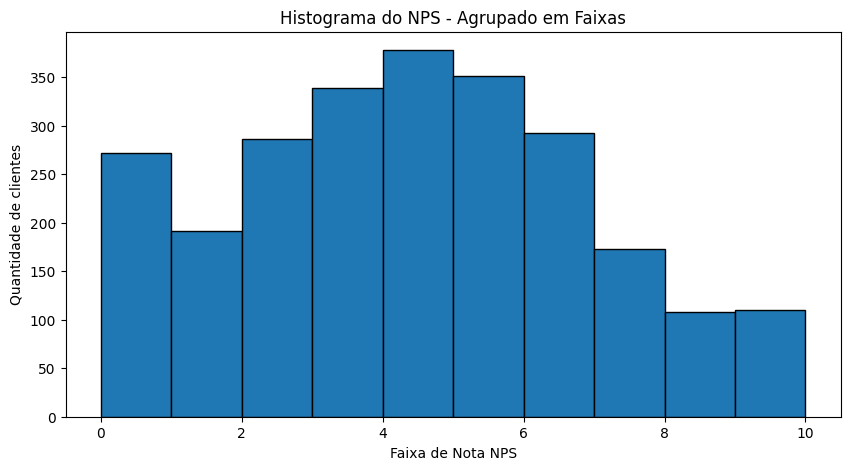

In [9]:
plt.figure(figsize=(10,5))
plt.hist(df["nps_score"], bins=10, edgecolor='black')
plt.xlabel("Faixa de Nota NPS")
plt.ylabel("Quantidade de clientes")
plt.title("Histograma do NPS - Agrupado em Faixas")
plt.show()

# Analisando o Histograma

Ao agrupar as notas em faixas, buscamos identificar regiões de maior concentração de avaliações. Não fazendo diferença entre um cliente que dá uma nota 4.0, 4.1 e 4.2 por exemplo.

O histograma sugere uma grande concentração no intervalo de 3 a 6. O que significa que temos um cenário predominantemente de detratores.

Uma caracteristica do NPS é que geralmente os clientes que tendem a avaliar se concentram em 0-1 e 9-10.<br>
Isso porque quem avalia são clientes que geralmente estão extremamente satisfeitos ou extremamente insatisfeitos.<br>
Porém em nosso histograma vemos um cenário bem diferente. Ele está concentrado mais na região central.<br>
Isso acontece porque esse tipo de agrupamento pode esconder comportamentos extremos. Para entender melhor esse ponto, precisamos analisar a frequência das notas individualmente, sem agrupamentos.

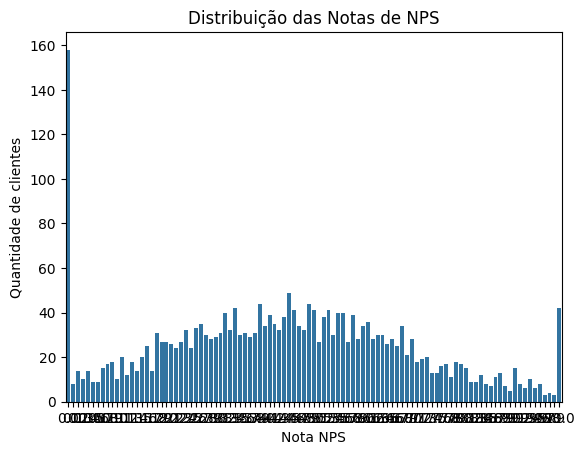

In [10]:
sns.countplot(x="nps_score", data=df)
plt.xlabel("Nota NPS")
plt.ylabel("Quantidade de clientes")
plt.title("Distribuição das Notas de NPS")
plt.show()

# Histograma - Frequência Individual

Ao observar as notas de forma individual, temos um cenário bem diferente, é revelado um comportamento extremamente relevante.

A nota **0** aparece como a mais frequente, revelando um grupo significativo de clientes extremamente insatisfeitos. Numa grandeza, onde apenas olhando o gráfico, é aproximadamente 3 vezes maior que qualquer outra.

Percebemos aqui um ponto importante: o agrupamento do histograma mascarava esse comportamento extremo, pois a grande quantidade de valores possíveis entre 3 e 6 diluía visualmente o impacto do zero.

Para uma explicação mais clara: Temos uma boa quantidade de cliente que dão nota 4.0 e 4.5 por exemplo, mas poucos dão 0.1 ou 0.2 ao inves de 0 e isso derruba o intervalo de 0 a 1. O mesmo percebe-se na nota 10, onde poucos dão os valores logo abaixo como 9.9 ou 9.8, assim o intervalo de 9 a 10 também sofre na visualização de intervalos.

**Esse é um insight crítico para a análise.**<br>
Apesar de os clientes que deram nota 0 serem esmagadoramente a maioria, os clientes no range de 3 a 6 superam em quantidade os clientes 0. Temos aqui então dois pontos em que podemos atuar, nos clientes extremamente insatisfeitos e nos que estão moderadamente insatisfeitos e a depender dos dados, podemos ver como o que os diferencia e onde atuar para cada grupo.

# Clientes por Categorias de NPS

Vamos dividir os clientes agora nas categorias de detratores, neutros e promotores para encontrarmos a quantidade de clientes em cada uma.

In [11]:
def categorize_nps(score):
    if score < 7:
        return "Detrator"
    elif score < 9:
        return "Neutro"
    else:
        return "Promotor"

df["nps_category"] = df["nps_score"].apply(categorize_nps)
df[["nps_score", "nps_category"]].head()

,nps_score,nps_category
0,6.9,Detrator
1,2.4,Detrator
2,4.8,Detrator
3,5.9,Detrator
4,6.1,Detrator


Analisamos a quantidade absoluta de clientes em cada categoria.

In [12]:
df["nps_category"].value_counts()

nps_category
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

E aqui visualizamos essa distribuição de forma percentual.

In [13]:
df["nps_category"].value_counts(normalize=True) * 100

nps_category
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64

A proporção revela um cenário crítico.<br>
Uma quantidade muito superior de detratores em relação a neutros e promotores.

# Primeira Hipótese

Uma hipótese clássica em e-commerce é que atrasas na entrega impactam fortemente a satisfação do cliente.<br>
Começamos testando essa hipótese para verificar se o comportamento observado nos dados confirma essa suposição.

Importante: Até o momento, não temos vimos dados que comprovem isso. Aqui estamos partindo de uma suposição por algo já fortemente _conhecido_ por impactar NPS, porém iremos investigar da maneira adequada para encontrar de fato o que realmente mais impacta, baseado em dados.


In [14]:
df.groupby("nps_category")["delivery_delay_days"].mean()

nps_category
Detrator    2.414889
Neutro      1.053381
Promotor    0.718182
Name: delivery_delay_days, dtype: float64

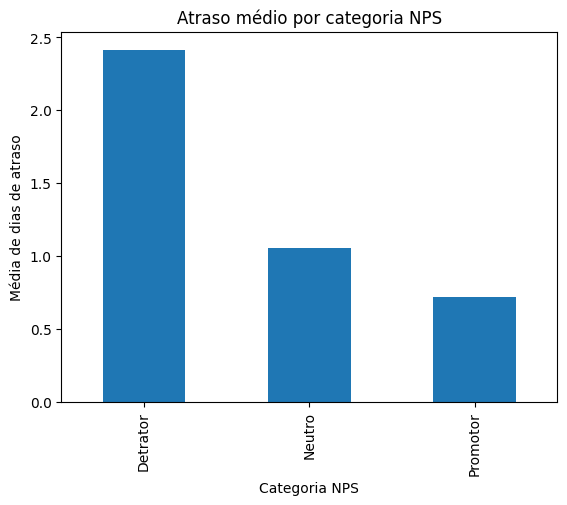

In [15]:
df.groupby("nps_category")["delivery_delay_days"].mean().plot(kind="bar")
plt.xlabel("Categoria NPS")
plt.ylabel("Média de dias de atraso")
plt.title("Atraso médio por categoria NPS")
plt.show()

In [16]:
dif_detrator_promotor = 2.534306/0.756219
print(dif_detrator_promotor)

3.351285804773485


A relação é clara: detratores apresentam, em média, cerca de 3.3 vezes mais atraso que promotores.

Isso já indica um forte indício de que a logística tem papel central na insatisfação.

Porém, como mencionado, essa análise foi baseada em uma hipótese e devemos tornar essa investigação mais objetiva (baseada em dados).

# Identificando Objetivamente as Variáveis Mais Relevantes

Em vez de escolher variáveis por intuição, comparamos todas as variáveis da base, medindo a diferença média entre Detratores e Promotores.

Esse método permite identificar, de forma quantitativa, quais fatores mais diferenciam quem odeia da marca de quem a recomenda.

In [17]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['customer_id', 'customer_age', 'customer_tenure_months', 'order_id',
       'order_value', 'items_quantity', 'discount_value',
       'payment_installments', 'delivery_time_days', 'delivery_delay_days',
       'freight_value', 'delivery_attempts', 'customer_service_contacts',
       'resolution_time_days', 'nps_score', 'repeat_purchase_30d',
       'complaints_count', 'csat_internal_score'],
      dtype='str')

In [18]:
diff_means = {}

for col in num_cols:
    mean_detrator = df[df["nps_category"] == "Detrator"][col].mean()
    mean_promotor = df[df["nps_category"] == "Promotor"][col].mean()
    diff_means[col] = mean_detrator - mean_promotor

diff_df = pd.DataFrame.from_dict(diff_means, orient="index", columns=["mean_diff"])
diff_df = diff_df.sort_values(by="mean_diff", ascending=False)

diff_df.head(10)

,mean_diff
complaints_count,2.169662
resolution_time_days,1.994642
delivery_delay_days,1.696707
customer_id,1.381590
order_id,1.381590
freight_value,1.247781
customer_service_contacts,0.959326
payment_installments,0.168624
delivery_time_days,0.057946
items_quantity,-0.153196


Ao analisar as diferenças, desconsideramos `complaints_count` e `resolution_time_days`.<br>
Isso porque o cliente não se torna detrator por reclamar — ele reclama porque algo deu errado antes.

A variável que mais se destaca é `delivery_delay_days`. Ela apresenta a maior diferença média entre detratores e promotores, indicando que o atraso na entrega é o fator operacional mais associado ao NPS.<br>
A hipótese anterior, de verificar essa variável estava correta mas agora podemos ver mais objetivamente que ela é de fato a que mais impacta o NPS.

Conclusão: A experiência de entrega (atrasos) é o fator operacional mais associado a insatisfação do cliente.

**Importante!**
As variáveis `complaints_count` e `resolution_time_days` não são as que mais fazem o NPS cair, pois elas são consequencia de algo que já deu errado.<br>
Elas estarem no topo da lista nos diz que clientes **detratores** reclamam muito mais e demoram muito mais para terem seus problemas resolvidos do que **neutros** e **promotores**.<br>


# Investigando os Dois Perfis de Detratores: Nota 0 vs Notas 3–6

A análise anterior mostrou grande concentração tanto na nota 0 quanto no intervalo 3–6.

Isso levanta uma questão importante: será que esses dois grupos representam níveis diferentes de insatisfação? Ou então motivos diferentes?

Vamos analisar os diferentes cenários.

In [19]:
df["is_zero"] = (df["nps_score"] == 0).astype(int)

In [20]:
df["is_36"] = df["nps_score"].between(3, 6).astype(int)

In [21]:
cols_analise = [
    "customer_age",
    "customer_tenure_months",
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",
    "delivery_time_days",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
    "repeat_purchase_30d"
]

In [22]:
results = []

for col in cols_analise:
    mean_zero = df[df["is_zero"] == 1][col].mean()
    mean_36 = df[df["is_36"] == 1][col].mean()
    diff = mean_zero - mean_36

    results.append([col, mean_zero, mean_36, diff])

diff_df = pd.DataFrame(
    results,
    columns=["variavel", "media_zero", "media_36", "diferenca"]
)

diff_df = diff_df.sort_values(by="diferenca", ascending=False)

diff_df

,variavel,media_zero,media_36,diferenca
7,delivery_delay_days,4.107595,2.019964,2.087631
0,customer_age,44.645570,42.990018,1.655551
12,complaints_count,5.759494,4.323049,1.436445
10,customer_service_contacts,2.651899,1.465517,1.186381
8,freight_value,39.106456,38.150127,0.956329
11,resolution_time_days,6.348101,5.500907,0.847194
1,customer_tenure_months,61.715190,61.037205,0.677985
6,delivery_time_days,8.164557,7.985481,0.179076
5,payment_installments,6.094937,6.063521,0.031416
14,repeat_purchase_30d,0.000000,0.000000,0.000000


# Entendendo a Comparação

Ao comparar esses dois grupos de detratores, conseguimos enxergar com clareza o ponto em que a frustração do cliente deixa de ser moderada e passa a ser extrema.<br>
É importante pesarmos o quanto a diferença realmente é relevante no valor das médias. Alguns valores podem ser maiores que outros mas percentualmente serem um impacto muito superior.<br>
Em nosso caso apenas observando os valores conseguimos deduzir isso, mas em um cenário com números maiores ou uma maior quantidade de variáveis, ordenar por percentual nos ajudaria a melhor entender.

### Principais Insights

- `delivery_delay_days` - Tempo no Atraso da Entrega

Disparado o que mais se destaca.

Clientes nota 0: **4.10 dias** de atraso<br>
Clientes nota 3–6: **2.02 dias** de atraso

O cliente nota 0 teve, aproximadamente, o dobro do atraso.<br>
Isso sugere a existência de um _limite de tolerância_: Atrasos de até ~2 dias geram frustração, mas quando o atraso ultrapassa esse ponto (se aproximando dos 4), a experiência se transforma em insatisfação extrema.

É um insight forte de que quanto mais atraso ocorre, maior a chance de o cliente dar nota 0.


- `csat_internal_score` - Atentimento ao Cliente

Aqui é outro fator onde existe uma diferença muito grande.

Clientes nota 0: **0.70**<br>
Clientes nota 3–6: **2.98**

É um forte indicativo que o atendimento ao cliente pode salvar uma experiência, ou ao menos não leva-lo a insatistação extrema.


- `complaints_count` e `customer_service_contacts` - Mais informações sobre Atendimento ao Cliente

Ambos campos estão reforçando a ideia de que o Atendimento ao Cliente é importante.<br>

Neste caso ele está nos dizendo:

Quanto menos contato o cliente precisar ter, mais probabilidade ele tem de apenas se frustrar (3-6) contra ficar extremamente insatisfeito (0).

Clientes nota 0: realizaram 5.75 reclamações<br>
Clientes nota 3-6: realizaram 4.3 reclamações<br>

Clientes nota 0: tiveram 2.65 contatos com o atendimento<br>
Clientes nota 3-6: tiveram 1.46 contatos com o atendimento

São valores menores que o atraso na entrega, e percentualmente é bem inferior, o que significa que tem menos impacto porém ainda assim é algo que agrava e acumula pra insatisfação do cliente.


- `delivery_time_days` - Tempo Total da Entrega

Podemos fazer dois insights bem interessante com esse dado.<br>
Quando olhamos os dados vemos que:

Clientes nota 0: 8.16 dias
Clientes nota 3-6: 7.98 dias

O primeiro insight é que devemos pensar em dias. Não podemos pensar 7,98 dias, isso se converte a 8 dias pois está muito mais próximo de 8 do que 7. E o mesmo para 8.16, também é praticamente 8. Então o tempo total da entrega em ambos os casos, em sua maioria, é quase o mesmo, com poquissima variação.<br>
Matematicamente é verdade que demora mais para o cliente nota 0, agravando a situação, mas realisticamente a diferença é inexistente.<br>

O segundo inshgit é que quando olhamos para o tempo do atraso (`delivery_delay_days`), uma variável relacionada ao tempo total, percebemos que ela tem muito mais impacto. O valor é o dobro enquanto aqui a diferença é de 0.18, um valor irrisório. Isso nos mostra que o prazo total da entrega não importa tanto, mas o fato de simplesmente atrasar, tem um peso muito maior.

Percebemos que a mesmo o atraso sendo o dobro no 0, o tempo total da entrega é quase idêntico em ambos os casos.
Isso mostra que o prazo total não importa tanto, mas o simples fato de atrasar, importa muito mais.

---

- `customer_age` - Perfil do Cliente

Aqui vemos que a diferença é muito pequena para justificar algum perfil de cliente que explique o comportamento.<br>
O que mostra que o problema é mais operacional e não do perfil do cliente.

---

- `repeat_purchase_30d` - Recompra

Pode ser um dado valioso a se investigar pois não basta apenas evitarmos um cliente 0 ir para 3-6 se quisermos manter ele (churn), temos que elevar o NPS a um nível onde ele volte a fazer compra.


Esse campo revela algo valiosíssimo!

Vamos raciocinar sobre ele.

Ele não é um dado que vai realmente impactar nosso NPS. A recompra geralmente acontece por clientes satisfeitos, clientes que já são um promotores.<br>
Porém, o que é importante para um e-commerce? Vender. Não importa se é um cliente novo ou antigo, o objetivo final é conseguir a venda.

Quando olhamos para nosso dado percebemos:

Independentemente de o cliente ser nota 0 ou 3–6, ambos já apresentam tendência nula de recompra no curto prazo. Ambos estão em 0.<br>

Com isso levanta-se uma pergunta:

Vale a pena recuperar um cliente do 0 para 3-6? Do ponto de vista de venda direta para esse cliente: Não.<br>
Porém, iriamos levantar um cliente extremamente insatisfeito para um insatisfeito. Apesar de ambos ainda serem detratores, a escala muda, e possivelmente o impacto negativo que o detrator tem sobre o e-commerce é menor. Seja no marketing boca a boca ou qualquer outra fonte. E esse impacto menos negativo pode evitar perder ainda mais vendas.

Então qual deve ser o NPS mínimo para que um cliente faça uma nova compra? Para que retenhamos esse cliente e ele gere lucro?<br>
Não basta evitar que um cliente 0 vire nota 3-6.<br>
Para reduzir churn, é necessário elevar o NPS a um nível onde o cliente volte a realizar uma nova compra, ou seja, onde `repeat_purchase_30d` é maior que 0.

Esse ponto não faz parte da nossa pesquisa de NPS e funciona como uma análise extra que podemos fazer.

# Região

Como a logística é um fator determinante, a região pode explicar parte desse comportamento, pode ser que a logística esteja passando por problemas em alguma região. É um ponto que vale a pena investigarmos.

Analisamos se existem diferenças relevantes de NPS entre regiões e se essas diferenças estão associadas a variáveis operacionais, principalmente a `delivery_delay_days` (atraso na entrega) que é a que possui maior impacto no NPS.

In [23]:
region_analysis = (
    df
    .groupby("customer_region")
    .agg({
        "nps_score": "mean",
        "delivery_delay_days": "mean",
        "csat_internal_score": "mean",
        "complaints_count": "mean",
        "customer_service_contacts": "mean",
        "order_id": "count"
    })
    .rename(columns={"order_id": "orders"})
    .sort_values("nps_score")
)

region_analysis.head(10)

,nps_score,delivery_delay_days,csat_internal_score,complaints_count,customer_service_contacts,orders
customer_region,,,,,,
Centro-Oeste,4.209829,2.222222,3.022009,4.177350,1.591880,468
Sudeste,4.373846,2.217308,2.931538,4.242308,1.494231,520
Norte,4.382609,2.144269,2.935375,4.110672,1.456522,506
Nordeste,4.421649,2.185567,3.024124,4.162887,1.507216,485
Sul,4.490979,2.168906,2.808637,4.061420,1.552783,521


Observando esses dados percebemos que a região não tem quase qualquer impacto, ela não é um fator determinante.<br>
Percebemos um valor muito próximo entre todas elas e nenhuma se destaca das outras.

Conclusão: A região não tem qualquer impacto no NPS.

# Investigando a Relação entre NPS e Recompra

Durante nossa analise, quando comparamos o cliente 0 e o 3-6, percebemos que em ambos os casos ja os perdemos para uma nova compra nos próximos 30 dias (`repeat_purchase_30d`).<br>

Foi observado que do ponto de vista de venda (diretamente desse cliente) não importa se o NPS é 0 ou até 6, já não faremos uma venda a ele.<br>
É importante lembrar que mesmo ambos sendo detratores, é melhor ter um cliente detrator 6 do que 0, mas isso já é um ponto que iria requerer uma outra análise e possivelmente precisaria de outros dados para analisarmos mais fundo.

Mas para nossa análise, podemos pensar: Qual seria o NPS mínimo que devemos alcançar para que esse cliente volta a realizar uma compra nos próximos 30 dias? A partir de qual NPS começamos a ver uma nova compra? E onde mais se destaca o cliente que realiza uma nova compra para um que não volta a comprar?

Começamos buscando a probabilidade que cada NPS tem em realizar uma nova compra. E assim entender se existe um ponto mínimo de satisfação que aumenta a probabilidade dessa nova compra ocorrer.

In [24]:
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = ["0-1","1-2","2-3","3-4","4-5","5-6","6-7","7-8","8-9","9-10"]

df["nps_range"] = pd.cut(
    df["nps_score"],
    bins=bins,
    labels=labels,
    right=False  # intervalo [ , )
)

In [25]:
recompra_por_range = (
    df
    .groupby("nps_range")["repeat_purchase_30d"]
    .mean()
)

recompra_por_range

nps_range
0-1     0.0
1-2     0.0
2-3     0.0
3-4     0.0
4-5     0.0
5-6     0.0
6-7     0.0
7-8     0.0
8-9     1.0
9-10    1.0
Name: repeat_purchase_30d, dtype: float64

Os resultados encontrados aqui levantam um grande **Alerta Vermelho**.

É **extremamente improvável** que **100%** dos clientes com NPS >= 8 tenham recomprado e que absolutamente **nenhum** cliente abaixo disso tenha realizado nova compra. Mesmo com uma base de dados pequena, de 2500 clientes, é um número muito _"perfeito"_ o que levanta **fortes** suspeitas.

Isso indica um forte indício de que nossos dados **não** são confiáveis.

No início desse projeto, vimos que nossos dados são para testes, com finalidade de estudo. Por mais que possam vir de um banco de dados real, eles também podem terem sido criados artificialmente. É extremamente provável que o `repeat_purchase_30d` tenha sido preenchido a partir do valor de NPS. Seguindo alguma lógica de:<br>
"Se o NPS for maior que 8, então preencha recompra como 1/True"

Vamos ver essa informação agora em valores absolutos:

In [26]:
bins = list(range(0, 11))

df["nps_range"] = pd.cut(
    df["nps_score"],
    bins=bins,
    right=False, # intervalo fechado à esquerda: [0,1)
    include_lowest=True
)

In [27]:
ct = pd.crosstab(df["nps_range"], df["repeat_purchase_30d"])
ct

repeat_purchase_30d,0,1
nps_range,,
"[0, 1)",272,0
"[1, 2)",191,0
"[2, 3)",286,0
"[3, 4)",339,0
"[4, 5)",378,0
"[5, 6)",351,0
"[6, 7)",292,0
"[7, 8)",173,0
"[8, 9)",0,108


Essa evidência confirma a suspeita: os dados de recompra não são confiáveis para essa análise.

Verificamos percentualmente que algo estava errado e agora em números absolutos.

Isso inviabiliza a análise que fariamos: de descobrir de a partir de qual NPS devemos focar em recuperar o cliente para que ele volte a recomprar. A ideia era ver os dados desse range para determinar que o mínimo que devemos focar é ter um cliente com NPS **x**, onde **x** é um valor que escolheriamos para se ter como meta.

Ou seja, buscar o NPS onde a recompra seja maior que 0 (0%).

Caso fosse 0.05 (5%) já seria alguma coisa e uma meta a focar: Manter o NPS dos cliente no minimo nesse valor.<br>
Se quisessemos 0.15 (15%), aumentariamos a meta do NPS para esse outro valor. Aqui seguindo um objetivo de negócio e estratégia.

É uma analise que não podemos fazer com esses dados, mas ainda assim **uma análise de que não é possivel fazer a análise**.

Dessa forma, não é possível determinar com segurança qual seria o NPS mínimo necessário para incentivar uma nova compra.

# Conclusão da Análise Exploratória

A análise revelou que a satisfação do cliente está fortemente ligada a fatores operacionais da experiência de compra, principalmente a logística de entrega.

Variáveis como região, idade e tempo de relacionamento apresentaram impacto mínimo no NPS. Em contrapartida, o atraso na entrega se mostrou o principal fator associado a insatisfação extrema.

Também identificamos dois níveis distintos de detratores:
- Clientes frustrados (3–6)
- Clientes extremamente insatisfeitos (0)

Essa distinção de detratores foi capaz de medir o quanto e onde seria necessário atuar em uma melhoria para recuperar um cliente nota 0 para 3-6.

Além disso, a investigação sobre recompra foi capaz de identificar inconsistências nos dados, evitando conclusões incorretas.

Essa análise deixa claro que melhorias operacionais na logística têm potencial direto de elevar significativamente o NPS do e-commerce.